In [1]:
!pip install spacy hdbscan scikit-learn pandas numpy matplotlib seaborn -q
!python -m spacy download en_core_web_sm -q
print('✅ Done! All libraries installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 101.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Done! All libraries installed.


In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
import hdbscan

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('darkgrid')
RANDOM_STATE = 42

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [3]:
from google.colab import files
uploaded = files.upload()
print('✅ File uploaded!')

Saving Resume.csv to Resume.csv
✅ File uploaded!


In [4]:
df = pd.read_csv('Resume.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Total Resumes:', len(df))
print('Unique Categories:', df['Category'].nunique())
print()
print(df['Category'].value_counts())

Shape: (2484, 4)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']
Total Resumes: 2484
Unique Categories: 24

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [5]:
df['text_length'] = df['Resume_str'].str.len()

print('Resume text length stats:')
print(df['text_length'].describe())

# Drop very short resumes (bad data)
before = len(df)
df = df[df['text_length'] > 100].reset_index(drop=True)
print(f'\nDropped {before - len(df)} bad rows')
print(f'Clean dataset size: {len(df)}')

Resume text length stats:
count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: text_length, dtype: float64

Dropped 1 bad rows
Clean dataset size: 2483


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # Remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)             # Remove emails
    text = re.sub(r'[^a-z\s]', ' ', text)            # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()         # Normalize spaces
    return text

# Apply cleaning
df['clean_text'] = df['Resume_str'].apply(clean_text)

print('✅ Text cleaning done!')
print('\nOriginal sample:')
print(df['Resume_str'].iloc[0][:200])
print('\nCleaned sample:')
print(df['clean_text'].iloc[0][:200])

✅ Text cleaning done!

Original sample:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

Cleaned sample:
hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of


In [7]:
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

def lemmatize_text(doc):
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and len(token.text) > 2
        and token.is_alpha
    ]
    return ' '.join(tokens)

print('Starting lemmatization... (3-5 mins)')

lemmatized = []
texts = df['clean_text'].tolist()

for i, doc in enumerate(nlp.pipe(texts, batch_size=50)):
    lemmatized.append(lemmatize_text(doc))
    if (i + 1) % 500 == 0:
        print(f'  Processed {i+1}/{len(texts)}...')

df['processed_text'] = lemmatized

print(f'✅ Lemmatization done! Total: {len(lemmatized)}')
print('\nSample processed text:')
print(df['processed_text'].iloc[0][:300])

Starting lemmatization... (3-5 mins)
  Processed 500/2483...
  Processed 1000/2483...
  Processed 1500/2483...
  Processed 2000/2483...
✅ Lemmatization done! Total: 2483

Sample processed text:
administrator marketing associate administrator summary dedicated customer service manager year experience hospitality customer service management respect builder leader customer focus team strive instill share enthusiastic commitment customer service highlight focus customer satisfaction team manag


In [8]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),      # Unigrams + Bigrams
    min_df=3,                # Must appear in at least 3 docs
    max_df=0.90,             # Ignore terms in >90% of docs
    sublinear_tf=True        # Log normalization
)

X_tfidf = tfidf.fit_transform(df['processed_text'])

print(f'TF-IDF Matrix Shape: {X_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_)}')
print(f'Sparsity: {100 * (1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])):.2f}%')
print('✅ TF-IDF done!')

TF-IDF Matrix Shape: (2483, 10000)
Vocabulary size: 10000
Sparsity: 96.55%
✅ TF-IDF done!


n_components=  50 → Explained Variance: 16.83%
n_components= 100 → Explained Variance: 22.78%
n_components= 150 → Explained Variance: 27.59%
n_components= 200 → Explained Variance: 31.85%
n_components= 300 → Explained Variance: 39.30%


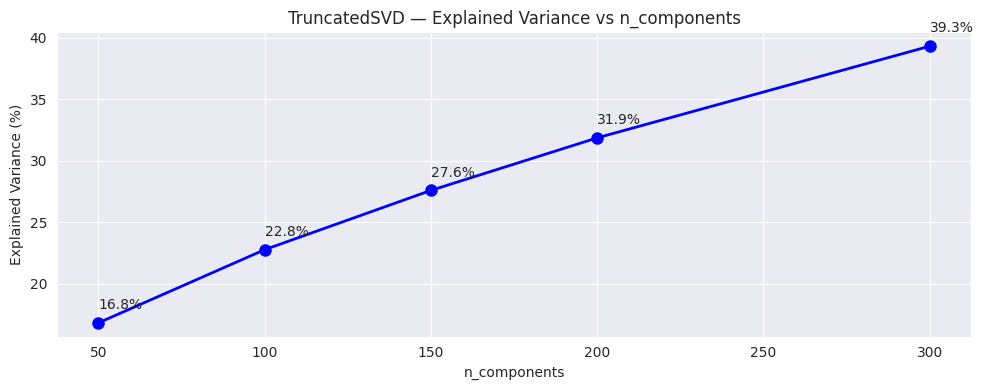

✅ Done!


In [9]:
components_to_try = [50, 100, 150, 200, 300]
variances = []

for n in components_to_try:
    svd_temp = TruncatedSVD(n_components=n, random_state=RANDOM_STATE)
    svd_temp.fit(X_tfidf)
    var = svd_temp.explained_variance_ratio_.sum()
    variances.append(var)
    print(f'n_components={n:4d} → Explained Variance: {var*100:.2f}%')

# Plot
plt.figure(figsize=(10, 4))
plt.plot(components_to_try, [v*100 for v in variances], 'bo-', linewidth=2, markersize=8)
plt.xlabel('n_components')
plt.ylabel('Explained Variance (%)')
plt.title('TruncatedSVD — Explained Variance vs n_components')
plt.grid(True)
for x, y in zip(components_to_try, variances):
    plt.annotate(f'{y*100:.1f}%', (x, y*100), textcoords='offset points', xytext=(0, 10))
plt.tight_layout()
plt.show()
print('✅ Done!')

In [10]:
BEST_N_COMPONENTS = 300

svd = TruncatedSVD(n_components=BEST_N_COMPONENTS, random_state=RANDOM_STATE)
normalizer = Normalizer(copy=False)

lsa = make_pipeline(svd, normalizer)
X_lsa = lsa.fit_transform(X_tfidf)

print(f'LSA Matrix Shape: {X_lsa.shape}')
print(f'Explained Variance: {svd.explained_variance_ratio_.sum()*100:.2f}%')
print('✅ SVD + L2 Normalization applied!')

LSA Matrix Shape: (2483, 300)
Explained Variance: 39.30%
✅ SVD + L2 Normalization applied!


In [11]:
k_range = range(5, 31)

inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_scores = []

print('Testing K values 5 to 30...')
for k in k_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=RANDOM_STATE
    )
    labels = km.fit_predict(X_lsa)

    inertias.append(km.inertia_)
    sil = silhouette_score(X_lsa, labels, sample_size=1000, random_state=RANDOM_STATE)
    silhouette_scores.append(sil)
    davies_bouldin_scores.append(davies_bouldin_score(X_lsa, labels))
    calinski_scores.append(calinski_harabasz_score(X_lsa, labels))

    print(f'  K={k:2d} | Inertia={km.inertia_:.0f} | Silhouette={sil:.4f}')

print('\n✅ Done testing all K values!')

Testing K values 5 to 30...
  K= 5 | Inertia=1862 | Silhouette=0.0393
  K= 6 | Inertia=1831 | Silhouette=0.0448
  K= 7 | Inertia=1803 | Silhouette=0.0506
  K= 8 | Inertia=1779 | Silhouette=0.0512
  K= 9 | Inertia=1758 | Silhouette=0.0516
  K=10 | Inertia=1739 | Silhouette=0.0542
  K=11 | Inertia=1725 | Silhouette=0.0527
  K=12 | Inertia=1711 | Silhouette=0.0550
  K=13 | Inertia=1700 | Silhouette=0.0569
  K=14 | Inertia=1685 | Silhouette=0.0590
  K=15 | Inertia=1675 | Silhouette=0.0554
  K=16 | Inertia=1663 | Silhouette=0.0573
  K=17 | Inertia=1657 | Silhouette=0.0582
  K=18 | Inertia=1647 | Silhouette=0.0570
  K=19 | Inertia=1638 | Silhouette=0.0582
  K=20 | Inertia=1630 | Silhouette=0.0585
  K=21 | Inertia=1625 | Silhouette=0.0571
  K=22 | Inertia=1617 | Silhouette=0.0581
  K=23 | Inertia=1607 | Silhouette=0.0540
  K=24 | Inertia=1604 | Silhouette=0.0609
  K=25 | Inertia=1601 | Silhouette=0.0539
  K=26 | Inertia=1592 | Silhouette=0.0547
  K=27 | Inertia=1591 | Silhouette=0.0522
  K=28

In [12]:
# Retry SVD with smaller components + cosine metric
from sklearn.metrics.pairwise import cosine_similarity

# Try 50 components instead
svd2 = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
normalizer2 = Normalizer(copy=False)
lsa2 = make_pipeline(svd2, normalizer2)
X_lsa2 = lsa2.fit_transform(X_tfidf)

print('Testing K with n_components=50...')
sil_scores2 = []
k_range = range(5, 31)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_lsa2)
    sil = silhouette_score(X_lsa2, labels, sample_size=1000, random_state=RANDOM_STATE)
    sil_scores2.append(sil)
    print(f'  K={k:2d} | Silhouette={sil:.4f}')

best_k = list(k_range)[np.argmax(sil_scores2)]
print(f'\n✅ Best K = {best_k} | Best Silhouette = {max(sil_scores2):.4f}')

Testing K with n_components=50...
  K= 5 | Silhouette=0.1010
  K= 6 | Silhouette=0.1137
  K= 7 | Silhouette=0.1223
  K= 8 | Silhouette=0.1337
  K= 9 | Silhouette=0.1329
  K=10 | Silhouette=0.1384
  K=11 | Silhouette=0.1422
  K=12 | Silhouette=0.1420
  K=13 | Silhouette=0.1479
  K=14 | Silhouette=0.1489
  K=15 | Silhouette=0.1555
  K=16 | Silhouette=0.1572
  K=17 | Silhouette=0.1595
  K=18 | Silhouette=0.1598
  K=19 | Silhouette=0.1592
  K=20 | Silhouette=0.1611
  K=21 | Silhouette=0.1585
  K=22 | Silhouette=0.1629
  K=23 | Silhouette=0.1567
  K=24 | Silhouette=0.1579
  K=25 | Silhouette=0.1563
  K=26 | Silhouette=0.1637
  K=27 | Silhouette=0.1554
  K=28 | Silhouette=0.1570
  K=29 | Silhouette=0.1513
  K=30 | Silhouette=0.1546

✅ Best K = 26 | Best Silhouette = 0.1637


In [13]:
from sklearn.preprocessing import normalize

# Use TF-IDF directly with L2 normalization (no SVD)
# This makes KMeans use cosine similarity which is best for text

X_cos = normalize(X_tfidf, norm='l2')

print('Testing K with pure TF-IDF + Cosine (no SVD)...')
sil_scores3 = []
k_range = range(5, 31)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cos)
    sil = silhouette_score(X_cos, labels, sample_size=1000,
                           random_state=RANDOM_STATE, metric='cosine')
    sil_scores3.append(sil)
    print(f'  K={k:2d} | Silhouette={sil:.4f}')

best_k3 = list(k_range)[np.argmax(sil_scores3)]
print(f'\n✅ Best K = {best_k3} | Best Silhouette = {max(sil_scores3):.4f}')

Testing K with pure TF-IDF + Cosine (no SVD)...
  K= 5 | Silhouette=0.0291
  K= 6 | Silhouette=0.0313
  K= 7 | Silhouette=0.0350
  K= 8 | Silhouette=0.0370
  K= 9 | Silhouette=0.0370
  K=10 | Silhouette=0.0374
  K=11 | Silhouette=0.0375
  K=12 | Silhouette=0.0368
  K=13 | Silhouette=0.0385
  K=14 | Silhouette=0.0379
  K=15 | Silhouette=0.0382
  K=16 | Silhouette=0.0363
  K=17 | Silhouette=0.0385
  K=18 | Silhouette=0.0367
  K=19 | Silhouette=0.0367
  K=20 | Silhouette=0.0358
  K=21 | Silhouette=0.0336
  K=22 | Silhouette=0.0349
  K=23 | Silhouette=0.0330
  K=24 | Silhouette=0.0303
  K=25 | Silhouette=0.0382
  K=26 | Silhouette=0.0328
  K=27 | Silhouette=0.0328
  K=28 | Silhouette=0.0235
  K=29 | Silhouette=0.0293
  K=30 | Silhouette=0.0289

✅ Best K = 17 | Best Silhouette = 0.0385


In [14]:
!pip install sentence-transformers -q
print('✅ Sentence Transformers installed!')

✅ Sentence Transformers installed!


In [15]:
from sentence_transformers import SentenceTransformer

# Load pretrained model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Use processed text
texts = df['processed_text'].tolist()

print('Generating BERT embeddings...')
print('(This takes 5-10 mins, be patient!)')

X_bert = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f'\n✅ Embeddings shape: {X_bert.shape}')
print('Each resume is now a 384-dimensional semantic vector!')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating BERT embeddings...
(This takes 5-10 mins, be patient!)


Batches:   0%|          | 0/39 [00:00<?, ?it/s]


✅ Embeddings shape: (2483, 384)
Each resume is now a 384-dimensional semantic vector!


In [16]:
from sklearn.preprocessing import normalize

# Normalize BERT embeddings
X_bert_norm = normalize(X_bert, norm='l2')

print('Testing K values on BERT embeddings...')
bert_sil_scores = []
bert_inertias = []
k_range = range(5, 31)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_bert_norm)
    sil = silhouette_score(X_bert_norm, labels, sample_size=1000,
                           random_state=RANDOM_STATE)
    bert_sil_scores.append(sil)
    bert_inertias.append(km.inertia_)
    print(f'  K={k:2d} | Inertia={km.inertia_:.0f} | Silhouette={sil:.4f}')

best_k_bert = list(k_range)[np.argmax(bert_sil_scores)]
print(f'\n✅ Best K = {best_k_bert} | Best Silhouette = {max(bert_sil_scores):.4f}')

Testing K values on BERT embeddings...
  K= 5 | Inertia=834 | Silhouette=0.0647
  K= 6 | Inertia=799 | Silhouette=0.0828
  K= 7 | Inertia=777 | Silhouette=0.0721
  K= 8 | Inertia=758 | Silhouette=0.0802
  K= 9 | Inertia=740 | Silhouette=0.0885
  K=10 | Inertia=726 | Silhouette=0.0943
  K=11 | Inertia=714 | Silhouette=0.0940
  K=12 | Inertia=705 | Silhouette=0.0956
  K=13 | Inertia=698 | Silhouette=0.0913
  K=14 | Inertia=691 | Silhouette=0.0896
  K=15 | Inertia=684 | Silhouette=0.0957
  K=16 | Inertia=678 | Silhouette=0.0878
  K=17 | Inertia=672 | Silhouette=0.0873
  K=18 | Inertia=667 | Silhouette=0.0857
  K=19 | Inertia=662 | Silhouette=0.0831
  K=20 | Inertia=658 | Silhouette=0.0854
  K=21 | Inertia=654 | Silhouette=0.0809
  K=22 | Inertia=651 | Silhouette=0.0765
  K=23 | Inertia=648 | Silhouette=0.0804
  K=24 | Inertia=644 | Silhouette=0.0799
  K=25 | Inertia=641 | Silhouette=0.0795
  K=26 | Inertia=638 | Silhouette=0.0785
  K=27 | Inertia=633 | Silhouette=0.0796
  K=28 | Inertia=6

In [17]:
!pip install umap-learn -q
print('✅ UMAP installed!')

✅ UMAP installed!


In [18]:
import umap

print('Reducing BERT embeddings with UMAP...')

reducer = umap.UMAP(
    n_components=50,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=RANDOM_STATE
)

X_umap = reducer.fit_transform(X_bert_norm)

print(f'✅ UMAP done! Shape: {X_umap.shape}')
print('Reduced from 384 → 50 dimensions')

Reducing BERT embeddings with UMAP...
✅ UMAP done! Shape: (2483, 50)
Reduced from 384 → 50 dimensions


In [19]:
from sklearn.preprocessing import normalize

X_umap_norm = normalize(X_umap, norm='l2')

print('Testing K values on BERT + UMAP embeddings...')
umap_sil_scores = []
umap_inertias = []
k_range = range(5, 31)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_umap_norm)
    sil = silhouette_score(X_umap_norm, labels, sample_size=1000,
                           random_state=RANDOM_STATE)
    umap_sil_scores.append(sil)
    umap_inertias.append(km.inertia_)
    print(f'  K={k:2d} | Inertia={km.inertia_:.0f} | Silhouette={sil:.4f}')

best_k_umap = list(k_range)[np.argmax(umap_sil_scores)]
print(f'\n✅ Best K = {best_k_umap} | Best Silhouette = {max(umap_sil_scores):.4f}')

Testing K values on BERT + UMAP embeddings...
  K= 5 | Inertia=4 | Silhouette=0.4430
  K= 6 | Inertia=3 | Silhouette=0.4278
  K= 7 | Inertia=3 | Silhouette=0.4840
  K= 8 | Inertia=2 | Silhouette=0.5137
  K= 9 | Inertia=1 | Silhouette=0.5421
  K=10 | Inertia=1 | Silhouette=0.5760
  K=11 | Inertia=1 | Silhouette=0.5832
  K=12 | Inertia=1 | Silhouette=0.5906
  K=13 | Inertia=1 | Silhouette=0.5794
  K=14 | Inertia=1 | Silhouette=0.5764
  K=15 | Inertia=1 | Silhouette=0.5770
  K=16 | Inertia=1 | Silhouette=0.5534
  K=17 | Inertia=1 | Silhouette=0.5816
  K=18 | Inertia=0 | Silhouette=0.5421
  K=19 | Inertia=0 | Silhouette=0.5459
  K=20 | Inertia=0 | Silhouette=0.5421
  K=21 | Inertia=0 | Silhouette=0.5400
  K=22 | Inertia=0 | Silhouette=0.5288
  K=23 | Inertia=0 | Silhouette=0.5329
  K=24 | Inertia=0 | Silhouette=0.5320
  K=25 | Inertia=0 | Silhouette=0.5460
  K=26 | Inertia=0 | Silhouette=0.5342
  K=27 | Inertia=0 | Silhouette=0.5493
  K=28 | Inertia=0 | Silhouette=0.5446
  K=29 | Inertia=0

In [20]:
FINAL_K = 12

final_km = KMeans(
    n_clusters=FINAL_K,
    init='k-means++',
    max_iter=500,
    n_init=20,
    random_state=RANDOM_STATE
)

df['cluster'] = final_km.fit_predict(X_umap_norm)

sil_final = silhouette_score(X_umap_norm, df['cluster'])
db_final = davies_bouldin_score(X_umap_norm, df['cluster'])
ch_final = calinski_harabasz_score(X_umap_norm, df['cluster'])

print('='*50)
print('     FINAL MODEL EVALUATION')
print('='*50)
print(f'  K:                  {FINAL_K}')
print(f'  Silhouette Score:   {sil_final:.4f}')
print(f'  Davies-Bouldin:     {db_final:.4f}')
print(f'  Calinski-Harabasz:  {ch_final:.2f}')
print('='*50)

     FINAL MODEL EVALUATION
  K:                  12
  Silhouette Score:   0.5819
  Davies-Bouldin:     0.5623
  Calinski-Harabasz:  4494.95


In [21]:
print('Real categories per cluster:')
print('='*60)
for cid in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cid]
    top_cats = subset['Category'].value_counts().head(4)
    print(f'\nCluster {cid:2d} ({len(subset):3d} resumes):')
    for cat, cnt in top_cats.items():
        print(f'   {cat}: {cnt}')

Real categories per cluster:

Cluster  0 (191 resumes):
   FINANCE: 85
   BANKING: 71
   AGRICULTURE: 6
   BPO: 4

Cluster  1 (227 resumes):
   HEALTHCARE: 76
   ADVOCATE: 57
   CONSULTANT: 12
   FITNESS: 11

Cluster  2 (332 resumes):
   CONSTRUCTION: 93
   ENGINEERING: 84
   AVIATION: 78
   AGRICULTURE: 20

Cluster  3 (120 resumes):
   CHEF: 104
   ARTS: 5
   PUBLIC-RELATIONS: 4
   SALES: 2

Cluster  4 (343 resumes):
   BUSINESS-DEVELOPMENT: 92
   DIGITAL-MEDIA: 68
   PUBLIC-RELATIONS: 66
   CONSULTANT: 36

Cluster  5 (166 resumes):
   TEACHER: 96
   ARTS: 36
   DESIGNER: 8
   AGRICULTURE: 6

Cluster  6 (268 resumes):
   HR: 99
   PUBLIC-RELATIONS: 25
   ADVOCATE: 17
   ARTS: 16

Cluster  7 (249 resumes):
   INFORMATION-TECHNOLOGY: 96
   CONSULTANT: 43
   ENGINEERING: 25
   BANKING: 11

Cluster  8 (301 resumes):
   SALES: 97
   APPAREL: 40
   ADVOCATE: 29
   FITNESS: 16

Cluster  9 ( 75 resumes):
   DESIGNER: 50
   APPAREL: 20
   DIGITAL-MEDIA: 3
   SALES: 1

Cluster 10 ( 66 resumes):

In [22]:
cluster_names = {
    0:  'Finance & Banking',
    1:  'Healthcare & Law',
    2:  'Engineering & Construction',
    3:  'Culinary & Hospitality',
    4:  'Business & Media',
    5:  'Education & Arts',
    6:  'HR & People Management',
    7:  'Information Technology',
    8:  'Sales & Retail',
    9:  'Design & Fashion',
    10: 'Fitness & Wellness',
    11: 'Accounting & Finance'
}

df['cluster_name'] = df['cluster'].map(cluster_names)

print('Cluster assignments:')
for cid, name in cluster_names.items():
    size = (df['cluster'] == cid).sum()
    print(f'  Cluster {cid:2d} ({size:3d} resumes) → {name}')

Cluster assignments:
  Cluster  0 (191 resumes) → Finance & Banking
  Cluster  1 (227 resumes) → Healthcare & Law
  Cluster  2 (332 resumes) → Engineering & Construction
  Cluster  3 (120 resumes) → Culinary & Hospitality
  Cluster  4 (343 resumes) → Business & Media
  Cluster  5 (166 resumes) → Education & Arts
  Cluster  6 (268 resumes) → HR & People Management
  Cluster  7 (249 resumes) → Information Technology
  Cluster  8 (301 resumes) → Sales & Retail
  Cluster  9 ( 75 resumes) → Design & Fashion
  Cluster 10 ( 66 resumes) → Fitness & Wellness
  Cluster 11 (145 resumes) → Accounting & Finance


Running t-SNE... (3-5 mins)
✅ t-SNE done!


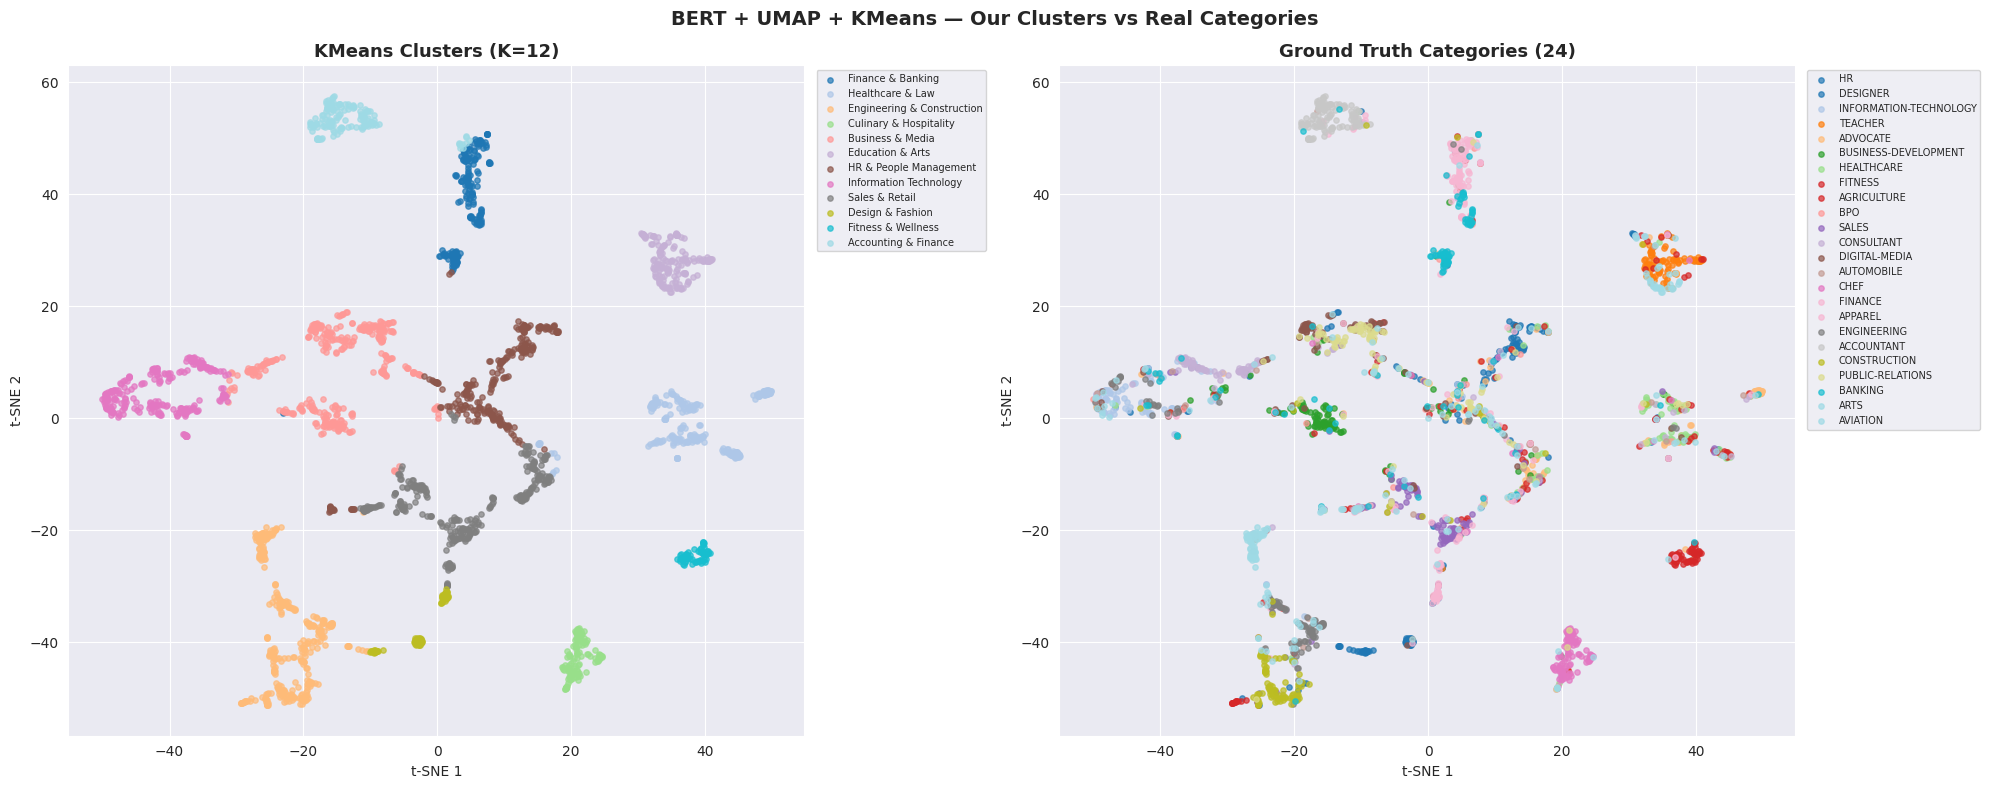

✅ Saved tsne_visualization.png


In [23]:
print('Running t-SNE... (3-5 mins)')

tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    n_iter=1000,
    random_state=RANDOM_STATE
)

X_tsne = tsne.fit_transform(X_umap)

df['tsne_x'] = X_tsne[:, 0]
df['tsne_y'] = X_tsne[:, 1]

print('✅ t-SNE done!')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
colors = cm.tab20(np.linspace(0, 1, 12))

# Left: Our clusters
for cid in range(12):
    mask = df['cluster'] == cid
    axes[0].scatter(df.loc[mask, 'tsne_x'], df.loc[mask, 'tsne_y'],
                    c=[colors[cid]], label=cluster_names[cid],
                    alpha=0.7, s=15)
axes[0].set_title('KMeans Clusters (K=12)', fontsize=13, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

# Right: Real categories
categories = df['Category'].unique()
cat_colors = cm.tab20(np.linspace(0, 1, len(categories)))
for i, cat in enumerate(categories):
    mask = df['Category'] == cat
    axes[1].scatter(df.loc[mask, 'tsne_x'], df.loc[mask, 'tsne_y'],
                    c=[cat_colors[i]], label=cat, alpha=0.7, s=15)
axes[1].set_title('Ground Truth Categories (24)', fontsize=13, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.suptitle('BERT + UMAP + KMeans — Our Clusters vs Real Categories',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved tsne_visualization.png')

In [24]:
os.makedirs('models', exist_ok=True)

# Save everything needed for Flask backend
with open('models/bert_model_name.pkl', 'wb') as f:
    pickle.dump('all-MiniLM-L6-v2', f)

with open('models/umap_reducer.pkl', 'wb') as f:
    pickle.dump(reducer, f)

with open('models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(final_km, f)

with open('models/cluster_names.pkl', 'wb') as f:
    pickle.dump(cluster_names, f)

# Save results CSV
df[['ID', 'Category', 'cluster', 'cluster_name']].to_csv('models/cluster_results.csv', index=False)

print('✅ All models saved!')
print('Files in models/:')
for f in os.listdir('models'):
    print(f'  {f}')

✅ All models saved!
Files in models/:
  umap_reducer.pkl
  cluster_results.csv
  bert_model_name.pkl
  kmeans_model.pkl
  cluster_names.pkl


In [25]:
from sentence_transformers import SentenceTransformer

def predict_cluster(resume_text):
    # Step 1: Clean
    text = re.sub(r'http\S+|www\.\S+', ' ', resume_text.lower())
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 2: BERT embedding
    bert = SentenceTransformer('all-MiniLM-L6-v2')
    embedding = bert.encode([text], convert_to_numpy=True)

    # Step 3: Normalize
    from sklearn.preprocessing import normalize
    embedding_norm = normalize(embedding, norm='l2')

    # Step 4: UMAP reduce
    embedding_umap = reducer.transform(embedding_norm)

    # Step 5: Normalize again
    embedding_umap_norm = normalize(embedding_umap, norm='l2')

    # Step 6: Predict cluster
    cluster_id = final_km.predict(embedding_umap_norm)[0]
    cluster_name = cluster_names[cluster_id]

    return cluster_id, cluster_name

# Test with a sample IT resume
test_resume = """
Experienced software engineer with 5 years of experience in Python,
Java and cloud computing. Worked on machine learning models, REST APIs,
AWS deployments and Docker containers. Strong knowledge of data structures
and algorithms.
"""

cid, cname = predict_cluster(test_resume)
print(f'✅ Predicted Cluster: {cid} → {cname}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Predicted Cluster: 7 → Information Technology


In [26]:
import shutil

# Zip the models folder
shutil.make_archive('skillmap_models', 'zip', 'models')
print('✅ Zipped!')

# Download
from google.colab import files
files.download('skillmap_models.zip')
print('✅ Download started!')

✅ Zipped!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!
